### Data Loading

IDD 20k dataset

In [ ]:
from collections import Counter
import glob
import json
from pathlib import Path

all_labels = Counter()
json_files = glob.glob("../data/raw/idd20kII/gtFine/**/**/*.json", recursive=True)
print(len(json_files))
for jf in json_files:  # sample first
    with open(jf) as f:
        d = json.load(f)
    for obj in d.get("objects", []):
        all_labels[obj["label"]] += 1

print(all_labels.most_common(50))

24267
[('obs-str-bar-fallback', 517908), ('vegetation', 468180), ('pole', 314661), ('billboard', 149130), ('motorcycle', 141576), ('rider', 123678), ('person', 102900), ('car', 89970), ('building', 84759), ('vehicle fallback', 64992), ('autorickshaw', 47211), ('drivable fallback', 46461), ('wall', 34107), ('truck', 33429), ('non-drivable fallback', 33192), ('curb', 31974), ('traffic sign', 29766), ('sky', 25191), ('road', 25164), ('fence', 12123), ('animal', 11889), ('bus', 10149), ('guard rail', 7782), ('sidewalk', 7272), ('fallback background', 7191), ('bicycle', 3222), ('bridge', 3165), ('polegroup', 2961), ('traffic light', 2340), ('out of roi', 756), ('caravan', 360), ('parking', 90), ('rail track', 63), ('rectification border', 45), ('train', 39), ('trailer', 30), ('tunnel', 15), ('ego vehicle', 12), ('ground', 9), ('unlabeled', 6), ('license plate', 6)]


In [34]:
all_labels["license plate"]

6

out of 24267 images only 6 have labelled license plate. Not useful

In [8]:
import ndjson
from pathlib import Path
path = Path(r"..\data\raw\plate.ndjson")
with open(path) as f:
    data = ndjson.load(f)
data

[{'type': 'dataset',
  'task': 'detect',
  'name': 'plate',
  'description': '',
  'bytes': 733364994,
  'url': 'https://platform.ultralytics.com/ultralytics-test/datasets/plate',
  'class_names': {'0': 'license_plate'},
  'version': 'latest',
  'created_at': '2026-07-07T09:03:50.709Z',
  'updated_at': '2026-07-07T09:04:56.120Z'},
 {'type': 'image',
  'file': 'Screenshot-2025-03-30-at-12_43_00-AM_png.rf.f2cc6cc995198026e0b304cf04b7a9e5.jpg',
  'url': 'https://cdn.ul.run/eu/i/e6a743d7f39074b2cdb06801c69afc4a.jpg?Expires=1784020001&KeyName=key-v1&Signature=EZ6IxLhSeJ7We7UxyCb7j1Ir7ZQ',
  'width': 640,
  'height': 640,
  'split': 'train'},
 {'type': 'image',
  'file': 'Screenshot-2025-03-09-at-11_27_19-PM_png.rf.4226f4c0e523f6160d0eb17544705ea3.jpg',
  'url': 'https://cdn.ul.run/eu/i/d4fc56344f25834ffc3b79349b9b2217.jpg?Expires=1784020001&KeyName=key-v1&Signature=W0FAIZ2xt-Q66Omr5W42AybtK-8',
  'width': 640,
  'height': 640,
  'split': 'train',
  'annotations': {'boxes': [[0, 0.10716, 0.3

In [6]:
path.exists()

False

In [2]:
!python -m ipykernel install --user --name=venv

Installed kernelspec venv in C:\Users\sys_a\AppData\Roaming\jupyter\kernels\venv


In [63]:
import pandas as pd
from pathlib import Path
result = Path(r"..\models\yolo\runs\yolo_pretrained_100ep\results.csv")
res = pd.read_csv(result)

<Axes: >

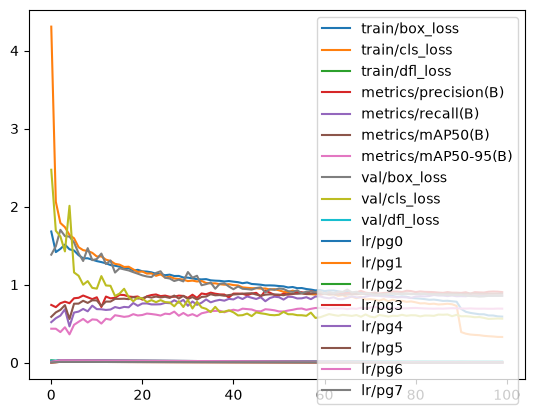

In [64]:
res.drop(['time', "epoch", ], axis=1).plot()

<Axes: >

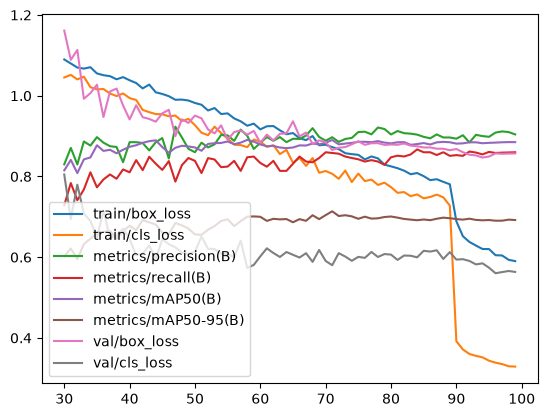

In [65]:
res.drop(["train/dfl_loss", "val/dfl_loss"], axis=1).iloc[30:, 2:10].plot()

In [66]:
res["metrics/precision(B)"].max()


np.float64(0.92333)

In [67]:
res["metrics/recall(B)"].max()

np.float64(0.86702)

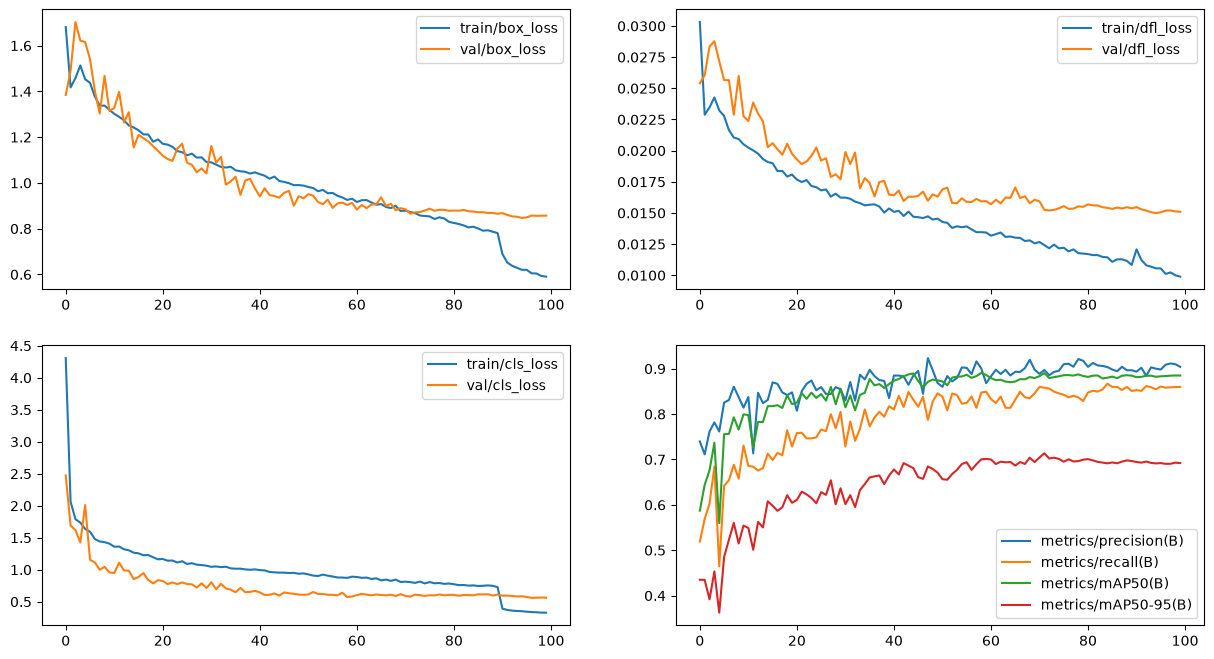

In [68]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,2, figsize=(15,8))
ax[0,0].plot(res[["train/box_loss", "val/box_loss"]], label=["train/box_loss", "val/box_loss"])
ax[0, 0].legend()
ax[0,1].plot(res[["train/dfl_loss", "val/dfl_loss"]], label=["train/dfl_loss", "val/dfl_loss"])
ax[0,1].legend()
ax[1,0].plot(res[["train/cls_loss", "val/cls_loss"]], label=["train/cls_loss", "val/cls_loss"])
ax[1,0].legend()
ax[1,1].plot(res[["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]], label=["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"])
ax[1,1].legend()
plt.show()

In [22]:
res

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,198.891,1.68091,4.30693,0.03031,0.73975,0.51909,0.58721,0.43494,1.38419,2.47250,0.02540,0.009962,0.003321,0.009962,0.003321,0.009962,0.003321,0.009962,0.003321
1,2,199.612,1.41693,2.06176,0.02288,0.71128,0.56915,0.64421,0.43473,1.49116,1.69089,0.02605,0.019764,0.006588,0.019764,0.006588,0.019764,0.006588,0.019764,0.006588
2,3,183.414,1.45785,1.79034,0.02347,0.76174,0.60284,0.67615,0.39178,1.70254,1.61826,0.02836,0.029368,0.009789,0.029368,0.009789,0.029368,0.009789,0.029368,0.009789
3,4,354.061,1.51324,1.73682,0.02427,0.78172,0.68440,0.73706,0.45329,1.62198,1.42572,0.02877,0.029109,0.009703,0.029109,0.009703,0.029109,0.009703,0.029109,0.009703
4,5,462.788,1.45296,1.63711,0.02323,0.76166,0.46462,0.55975,0.36245,1.61538,2.01033,0.02717,0.028812,0.009604,0.028812,0.009604,0.028812,0.009604,0.028812,0.009604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,73,1861.060,0.86765,0.79419,0.01217,0.88559,0.85638,0.87950,0.70203,0.87110,0.61001,0.01520,0.008616,0.002872,0.008616,0.002872,0.008616,0.002872,0.008616,0.002872
73,74,1965.740,0.85762,0.81463,0.01246,0.89287,0.84929,0.88144,0.70395,0.87282,0.60159,0.01525,0.008319,0.002773,0.008319,0.002773,0.008319,0.002773,0.008319,0.002773
74,75,2071.200,0.85529,0.78614,0.01216,0.89554,0.84574,0.88319,0.70117,0.87961,0.59107,0.01537,0.008022,0.002674,0.008022,0.002674,0.008022,0.002674,0.008022,0.002674
75,76,2176.190,0.85356,0.80708,0.01221,0.90999,0.84252,0.88572,0.69511,0.88723,0.60081,0.01555,0.007725,0.002575,0.007725,0.002575,0.007725,0.002575,0.007725,0.002575


In [3]:
from ultralytics import YOLO
import sys
sys.path.insert(0, "../")
from config.config import config
model = YOLO(str(config.yolo_runs_dir / "yolo_pretrained_100ep" / "weights" / "best.pt"))
metrics = model.val(data=str(config.plate_data_yaml), plots=True)

Ultralytics 8.4.92  Python-3.13.2 torch-2.13.0+cu132 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 874.6331.6 MB/s, size: 93.5 KB)
val: Scanning C:\SHASWAT\Projects\Vehicle-Monitoring-System\data\raw\plate\val\labels.cache... 489 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 489/489 73.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 7.8it/s 4.0s<0.1s
                   all        489        564      0.898      0.858       0.89      0.712
Speed: 1.1ms preprocess, 4.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\SHASWAT\Projects\Vehicle-Monitoring-System\runs\detect\val


In [4]:
for conf in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    metrics = model.val(data=str(config.plate_data_yaml), conf=conf, plots=False, verbose=False)
    print(f"conf={conf}: P={metrics.box.mp:.3f}, R={metrics.box.mr:.3f}, mAP50={metrics.box.map50:.3f}")

Ultralytics 8.4.92  Python-3.13.2 torch-2.13.0+cu132 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 931.3337.1 MB/s, size: 95.8 KB)
val: Scanning C:\SHASWAT\Projects\Vehicle-Monitoring-System\data\raw\plate\val\labels.cache... 489 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 489/489 136.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 10.7it/s 2.9s0.2s
                   all        489        564      0.898      0.858      0.865      0.697
Speed: 1.0ms preprocess, 3.5ms inference, 0.0ms loss, 0.1ms postprocess per image
conf=0.1: P=0.898, R=0.858, mAP50=0.865
Ultralytics 8.4.92  Python-3.13.2 torch-2.13.0+cu132 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 959.1440.2 MB/s, size: 89.4 KB)
val: Scanning C:\SHASWAT\Projects\Vehicle-Monitoring-System\data\raw\plate\val\labels.cache... 489 images, 0 b

In [8]:
# scripts/inspect_misses.py
from pathlib import Path
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
from config.config import config

CONF_THRESHOLD = 0.4       # threshold for "counts as a real detection" in the miss calculation
LOW_CONF_DISPLAY = 0.1     # show ALL predictions above this, even weak ones, for diagnosis
IOU_MATCH_THRESHOLD = 0.5

def load_gt_boxes(label_path, img_w, img_h):
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            cls, xc, yc, w, h = map(float, line.split())
            x1 = (xc - w/2) * img_w
            y1 = (yc - h/2) * img_h
            x2 = (xc + w/2) * img_w
            y2 = (yc + h/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

def iou(box1, box2):
    x1 = max(box1[0], box2[0]); y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2]); y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

def find_missed_detections(model_path, val_images_dir, val_labels_dir, output_dir):
    model = YOLO(str(model_path))
    output_dir.mkdir(parents=True, exist_ok=True)
    miss_count = 0

    for img_path in val_images_dir.glob("*.jpg"):
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        label_path = val_labels_dir / (img_path.stem + ".txt")
        gt_boxes = load_gt_boxes(label_path, w, h)
        if not gt_boxes:
            continue

        # run at LOW threshold so we can see weak/near-miss predictions too
        results = model(str(img_path), conf=LOW_CONF_DISPLAY, verbose=False)
        all_preds = [(box.xyxy[0].tolist(), float(box.conf[0])) for box in results[0].boxes]

        # "counted as found" only uses predictions above the real threshold
        confident_preds = [p for p, c in all_preds if c >= CONF_THRESHOLD]

        missed = []
        for gt in gt_boxes:
            if not any(iou(gt, pred) >= IOU_MATCH_THRESHOLD for pred in confident_preds):
                missed.append(gt)

        if missed:
            miss_count += 1
            draw = ImageDraw.Draw(img)

            # ground truth misses in red
            for box in missed:
                draw.rectangle(box, outline="red", width=4)

            # ALL model predictions in green (even weak ones), labeled with confidence
            for box, conf in all_preds:
                color = "green" if conf >= CONF_THRESHOLD else "yellow"
                draw.rectangle(box, outline=color, width=2)
                draw.text((box[0], max(0, box[1] - 12)), f"{conf:.2f}", fill=color)

            img.save(output_dir / f"missed_{img_path.name}")

    print(f"Images with at least one missed plate: {miss_count}")
    print(f"Saved to {output_dir}")

find_missed_detections(
    model_path=config.yolo_runs_dir / "yolo_pretrained_100ep" / "weights" / "best.pt",
    val_images_dir=config.plate_dataset_dir / "val" / "images",
    val_labels_dir=config.plate_dataset_dir / "val" / "labels",
    output_dir=config.processed_data_dir / "missed_detections"
)

Images with at least one missed plate: 81
Saved to C:\SHASWAT\Projects\Vehicle-Monitoring-System\data\processed\missed_detections


In [1]:
from ultralytics import YOLO

model = YOLO("../models/yolo/runs/yolo_pretrained_100ep/weights/best.pt")

In [4]:
obj = model("../data/raw/plate/test/images/0234_04035_b_jpg.rf.ebc38f0e1a29c1e9634274d3c9389452.jpg", stream=True)

In [ ]:
obj.

<generator object BasePredictor.stream_inference at 0x0000020E219DD000>